# Formats in my own words

**What is the difference between a point, a line and a polygon, with one example each from your own diving or fieldwork?**
*   A **point** marks a singular, specific spot, like the exact location of a unique coral head I found during a dive.
*   A **line** defines a path or connection between points, such as the route I swam to survey a section of reef.
*   A **polygon** represents an enclosed area, like the outline of a marine protected area I'm studying.

**What is a GeoJSON, in one sentence you would say out loud to a colleague?**
GeoJSON is a human-readable text format that describes geographical shapes and their properties, making it super easy to share map data, especially online.

**Why can't I measure the area of an MPA in EPSG:4326?**
Measuring area in EPSG:4326 is inaccurate because it uses latitude and longitude degrees, which don't represent uniform distances across the curved Earth, so calculations will be distorted.

In [2]:
import geopandas as gpd
print(gpd.__version__)

1.1.4


In [3]:
# 1. unzip, and list the layers before assuming anything
import zipfile, geopandas as gpd

zipfile.ZipFile("WDPA_WDOECM_Sep2026_Public_555523929.zip").extractall("wdpa")
gdb = "wdpa/WDPA_WDOECM_Sep2026_Public_555523929.gdb"
print(gpd.list_layers(gdb))

                                   name geometry_type
0    WDPA_WDOECM_poly_Sep2026_555523929  MultiPolygon
1  WDPA_WDOECM_source_Sep2026_555523929          None


In [4]:
# 2. load the polygon layer
mpa = gpd.read_file(gdb, layer="WDPA_WDOECM_poly_Sep2026_555523929")

print("rows, columns:", mpa.shape)
print("CRS:", mpa.crs)
print("geometry types:", mpa.geom_type.unique())
print(mpa[["NAME", "DESIG_ENG", "STATUS_YR", "REP_AREA", "GIS_AREA"]])

rows, columns: (1, 34)
CRS: EPSG:4326
geometry types: ['MultiPolygon']
                                                NAME  \
0  Acantilados y Fondos Marinos de La Punta de La...   

                                           DESIG_ENG  STATUS_YR  REP_AREA  \
0  Special Areas of Conservation (Habitats Direct...       2015       0.0   

   GIS_AREA  
0  1.250058  


In [5]:
# 3. the CRS lesson, live
print("area in EPSG:4326 units:", mpa.geometry.area.iloc[0])
print("area in km2 via EPSG:25830:", mpa.to_crs(25830).geometry.area.iloc[0] / 1e6)

area in EPSG:4326 units: 0.00012609328477976883
area in km2 via EPSG:25830: 1.2491892760060619


/tmp/ipykernel_1875/3874003510.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  print("area in EPSG:4326 units:", mpa.geometry.area.iloc[0])


Text(0.5, 1.0, 'Acantilados y Fondos Marinos de La Punta de La Mona')

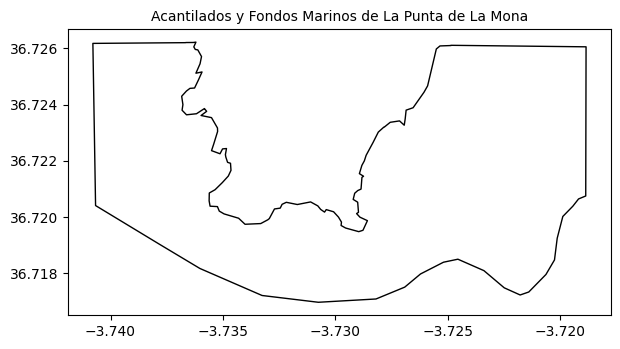

In [6]:
ax = mpa.plot(figsize=(7, 7), edgecolor="black", facecolor="none")
ax.set_title(mpa["NAME"].iloc[0], fontsize=10)

In [7]:
mpa.explore()